# Decision Tree Classification
### Definition
Decision tree algorithms use a tree of inequalities to classify data by maximizing the amount of information gain with the inequality among the features.

### Advantages
- Works well for a variety of tasks, as the distance function can be applied to many datasets
- Works for nonlinear data
- Simple implementation
### Disadvantages
- For larger datasets, prediction can be slow (sorting by the training data each time can be costly)
- Doesn't work well for data with overlap

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix

import struct

sns.set_theme()

# Data

We will load in the Titanic data that we created in the preprocessing step:

In [2]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/Titanic-Dataset"
train_X = np.load(f"{data_dir}/train_X.npy")
train_y = np.load(f"{data_dir}/train_y.npy")
test_X = np.load(f"{data_dir}/test_X.npy")
test_y = np.load(f"{data_dir}/test_y.npy")
PCA_train_X = np.load(f"{data_dir}/PCA_train_X.npy")
PCA_train_y = np.load(f"{data_dir}/PCA_train_y.npy")
PCA_test_X = np.load(f"{data_dir}/PCA_test_X.npy")
PCA_test_y = np.load(f"{data_dir}/PCA_test_y.npy")
train_X

array([[ 3.,  0., 22., ...,  1.,  0.,  0.],
       [ 1.,  1., 38., ...,  0.,  1.,  0.],
       [ 3.,  1., 26., ...,  0.,  1.,  0.],
       ...,
       [ 3.,  0., 27., ...,  1.,  0.,  0.],
       [ 1.,  0., 42., ...,  1.,  0.,  0.],
       [ 3.,  0., 20., ...,  1.,  0.,  0.]], shape=(622, 14))

In [3]:
tree = DecisionTreeClassifier(max_depth = 20)
tree.fit(PCA_train_X, PCA_train_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [4]:
print(export_text(tree, feature_names=["PC1", "PC2"]))

|--- PC2 <= 0.00
|   |--- PC2 <= -1.39
|   |   |--- PC2 <= -2.58
|   |   |   |--- PC2 <= -2.70
|   |   |   |   |--- PC1 <= 1.13
|   |   |   |   |   |--- PC2 <= -2.73
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- PC2 >  -2.73
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- PC1 >  1.13
|   |   |   |   |   |--- PC2 <= -3.35
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- PC2 >  -3.35
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- PC2 >  -2.70
|   |   |   |   |--- PC2 <= -2.58
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- PC2 >  -2.58
|   |   |   |   |   |--- class: 1
|   |   |--- PC2 >  -2.58
|   |   |   |--- PC1 <= 0.23
|   |   |   |   |--- class: 0
|   |   |   |--- PC1 >  0.23
|   |   |   |   |--- PC1 <= 0.40
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- PC1 >  0.40
|   |   |   |   |   |--- PC2 <= -2.27
|   |   |   |   |   |   |--- PC2 <= -2.44
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- PC2 

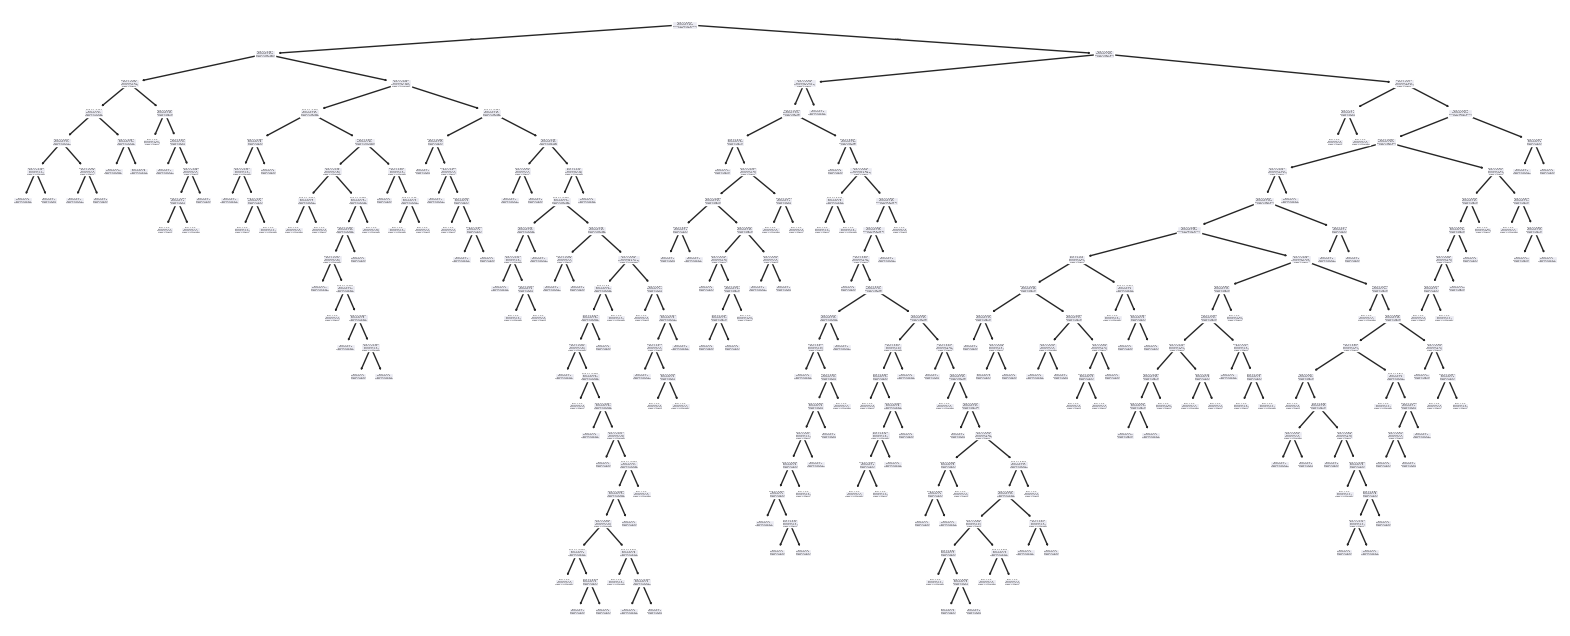

In [5]:
plt.figure(figsize=(20, 8))
plot_tree(tree, feature_names=["PC1", "PC2"], class_names=["Dead", "Survived"])
plt.show()

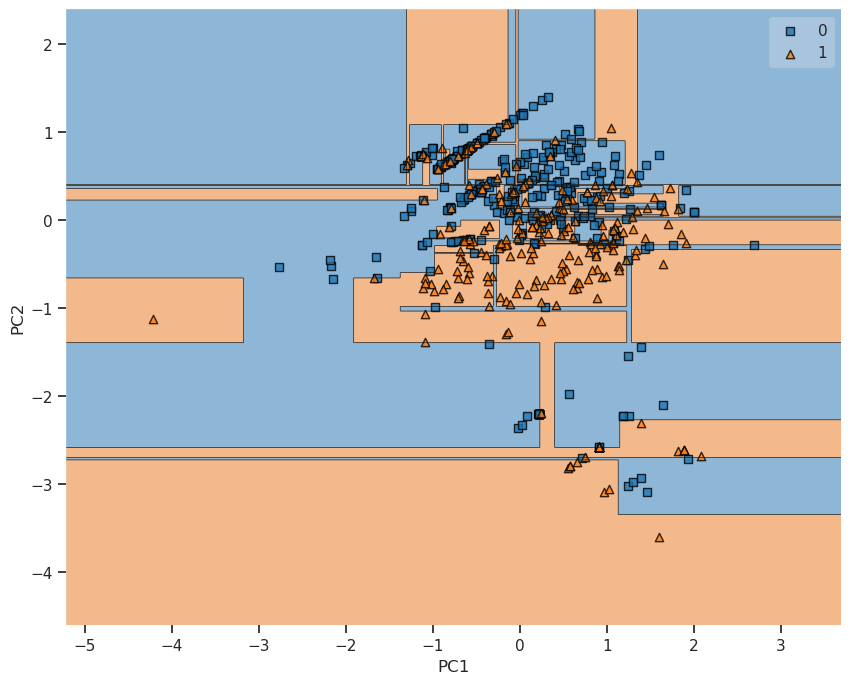

In [26]:
plt.figure(figsize = (10, 8))
plot_decision_regions(PCA_train_X, PCA_train_y.astype(np.int32), clf = tree)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()


In [30]:
test_predictions = tree.predict(PCA_test_X)
confusion_matrix = confusion_matrix(PCA_test_y, test_predictions)
conf_df = pd.DataFrame(confusion_matrix)
accurate_count = conf_df.iloc[0, 0] + conf_df.iloc[1, 1]
inaccurate_count = conf_df.iloc[1, 0] + conf_df.iloc[0, 1]
print(accurate_count / (accurate_count + inaccurate_count))

TypeError: 'numpy.ndarray' object is not callable